In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [2]:
import os
np.set_printoptions(legacy='1.25')
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
atom1, atom2 = 'Rb', 'Rb'
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')
energy_unit = 'GHz'
preferQuantumDefects = True


js = [[1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2]]

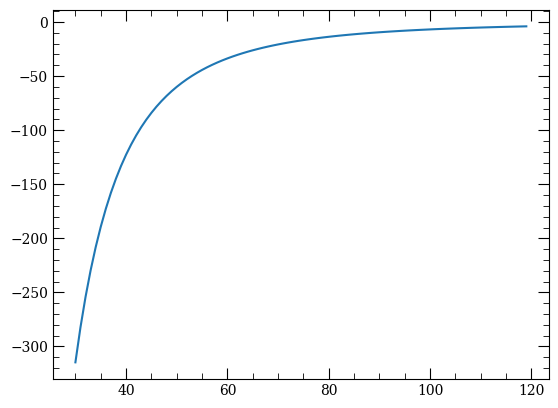

In [3]:
def defect_import(atom1, atom2, l1, l2, j1, j2, l1_1, l2_1, j1_1, j2_1, change1, change2, dif):
    path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {dif} {change1} {change2}.csv'

    data = pd.read_csv(path)
    ns, defects = data['n'], data['defect']
    return ns.to_numpy(), defects.to_numpy()

n1 = 65
n2 = 74
n1_1, n2_1 = 66, 72

l1, l2 = 1, 1
l1_1, l2_1 = 0, 0

j1, j2 = 1/2, 1/2
j1_1, j2_1 = 1/2, 1/2

change1 = 0
change2 = 0
dif = 0

ns, defect = defect_import(atom1, atom2, l1, l2, j1, j2, l1_1, l2_1, j1_1, j2_1, change1, change2, dif)
plt.figure()
plt.plot (ns, defect)
plt.show() 

In [ ]:
difs = np.arange(-8,9)
changes = np.arange(-3, 4)
ls = [2]
atom1, atom2 = 'Rb', 'Cs'
min_n = 30
max_n = 120
num=1
w=1
df = {'n1_0' : [], 'l1_0' : [], 'j1_0' : [],
                'n2_0' : [], 'l2_0' : [], 'j2_0' : [],
                'n1_1' : [], 'l1_1' : [], 'j1_1' : [],
                'n2_1' : [], 'l2_1' : [], 'j2_1' : [],
                'dif' : [], 'change1' : [], 'change2' : [],
                'defect' : [], 'c3k' : []}
for l in ls:
    for j1 in js[l]:
        for j2 in js[l]:
            for l1_1 in (l-1, l+1):
                if l1_1 < 0:
                    continue
                for l2_1 in (l-1, l+1):
                    if l2_1 < 0:
                        continue                    
                    
                    for dif in difs:
                        for change1 in changes:
                            
                            for change2 in changes:
                                jpdelta = []
                                labels = []
                                
                                for j1_1 in js[l1_1]:
                                    if abs(j1_1 - j1) > 1:
                                        continue

                                    for j2_1 in js[l2_1]: 
                                        if abs(j2_1 - j2) > 1:
                                            continue 
                                        
                                        data_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l]}{orbs[l]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {dif} {change1} {change2}.csv'

                                        if not os.path.exists(data_path):
                                            continue

                                        ns, defect = defect_import(atom1, atom2, l, l, j1, j2, l1_1, l2_1, j1_1, j2_1, change1, change2, dif)
                                        defect = list(defect)
                                        min_defect = min(np.array(defect), key=abs)

                                        for i in [-1,0,1]:

                                            try:
                                                assoc_n = ns[defect.index(min_defect) + i]
                                                delta = defect[defect.index(min_defect) + i]
                                                n1, n2 = assoc_n, assoc_n+dif
                                                n1_1, n2_1 = assoc_n+change1, assoc_n + change2 + dif
                                                ket1 = pi.KetAtom(atom1, n=assoc_n, l=l, j=j1, m=j1, s=1/2)
                                                ket2 = pi.KetAtom(atom1, n=assoc_n+dif, l=l, j=j2, m=j2, s=1/2)
                                                ket1_1 = pi.KetAtom(atom1, n=assoc_n+change1, l=l1_1, j=j1_1, m=j1_1, s=1/2)
                                                ket2_1 = pi.KetAtom(atom1, n=assoc_n+dif+change2, l=l2_1, j=j2_1, m=j2_1, s=1/2)
                                                            
                                            except  IndexError:
                                                continue


                                            if atom1 == 'Rb':
                                                rb_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n1, l, j1, n1_1, l1_1, j1_1)     
                                            else:
                                                rb_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n1, l, j1, n1_1, l1_1, j1_1)
                                            if atom2 == 'Rb':
                                                cs_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n2, l, j2, n2_1, l2_1, j2_1)     
                                            else:
                                                cs_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n2, l, j2, n2_1, l2_1, j2_1)

                                            c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * 1e9 * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*j1_1+1)/np.sqrt(2*j2_1+1)

                                            level_spacing = pi.KetAtom(atom1, n=assoc_n, l=l, j=j1, m=1/2).get_energy(unit = energy_unit) - pi.KetAtom(atom1, n=assoc_n+1, l=l, j=j1, m=1/2).get_energy(unit = energy_unit)

                                            if abs(delta) < 0.005 * abs(level_spacing) and abs(c3k) > 1:

                                                print(num)
                                                num+=1
                                                print(f'channel = {ket1}, {ket2} -> {ket1_1}, {ket2_1}')
                                                # print(f'channel {jps.index(jp)+1} = |Rb {c['n1_0']}s_1/2, Rb {c['n2_0']}s_1/2> -> |Rb {c['n1_1']}p_{c['j1_1']}, Rb {c['n2_1']}p_{c['j2_1']}>')
                                                print(f'min defect = {delta*1e3} MHz')
                                                print(f'c3k = {c3k}')
                                        
                                                df['n1_0'].append(n1)
                                                df['l1_0'].append(l)
                                                df['j1_0'].append(j1)
                                                df['n2_0'].append(n2)
                                                df['l2_0'].append(l)
                                                df['j2_0'].append(j2)
                                                df['n1_1'].append(n1_1)
                                                df['l1_1'].append(l1_1)
                                                df['j1_1'].append(j1_1)
                                                df['n2_1'].append(n2_1)
                                                df['l2_1'].append(l2_1)
                                                df['j2_1'].append(j2_1)
                                                df['dif'].append(dif)
                                                df['change1'].append(change1)
                                                df['change2'].append(change2)
                                                df['defect'].append(delta*1e3)
                                                df['c3k'].append(c3k)
                        print(f'ls: {int(list(ls).index(l)/len(ls)*100)}% | j1s: {int(list(js[l]).index(j1)/len(js[l])*100)}% | j2s: {int(list(js[l]).index(j2)/len(js[l])*100)}% | l1_1, l2_1: {l1_1},{l2_1} | difs: {int(list(difs).index(dif)/len(difs)*100)}%')



channelData_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channels\\{atom1}{atom2}.csv'

df = pd.DataFrame(df)
df.to_excel(channelData_path, index=False)

print(df)


j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 11%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 17%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 23%
1
channel = |Rb:81,S_1/2,1/2⟩, |Rb:78,S_1/2,1/2⟩ -> |Rb:80,P_1/2,1/2⟩, |Rb:78,P_1/2,1/2⟩
min defect = 6.2951773870736 MHz
c3k = 13.436400513664623
2
channel = |Rb:82,S_1/2,1/2⟩, |Rb:79,S_1/2,1/2⟩ -> |Rb:81,P_1/2,1/2⟩, |Rb:79,P_1/2,1/2⟩
min defect = -6.4328978769481 MHz
c3k = 14.159207238065012
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 29%
3
channel = |Rb:59,S_1/2,1/2⟩, |Rb:57,S_1/2,1/2⟩ -> |Rb:58,P_1/2,1/2⟩, |Rb:57,P_1/2,1/2⟩
min defect = -16.6278916876763 MHz
c3k = 3.543802615301663
4
channel = |Rb:71,S_1/2,1/2⟩, |Rb:69,S_1/2,1/2⟩ -> |Rb:70,P_3/2,3/2⟩, |Rb:69,P_1/2,1/2⟩
min defect = 9.326180559583 MHz
c3k = 8.014679886495918
5
channel = |Rb:72,S_1/2,1/2⟩, |Rb:70,S_1/2,1/2⟩ -> |Rb:71,P_3/2,3/2⟩, |Rb:70,P_1/2,1/2⟩
min defect = -8.0164031824097 MHz
c3k

In [7]:
df.sort_values(by='n1_0', ascending=True).to_csv(channelData_path + f'\\to {orbs[l1_1]}{orbs[l2_1]}.csv', index=False)
df.to_csv(channelData_path, index=False)
print(df.sort_values(by='n1_0', ignore_index=False))

PermissionError: [Errno 13] Permission denied: 'C:\\\\Users\\\\tommy\\\\OneDrive - Durham University\\\\level 4 Project\\\\Data\\\\channels\\\\RbCs\\\\ss\\\\j1j2(0.5,0.5)'